# EMA 6938 - Data Science for Materials
## Week 9 Lab Notebook: PCA, Dimensionality Reduction & Clustering

**Name:** *ANOSIKE KELECHI KENNETH*  
**Date:** *07/09/2026*  
**Kernel:** Python (matds)

---

**Chapters:** Sandfeld Ch. 15  
**Format:** Parts A–G in-class - due **Sunday 11:59 PM**  
**Dataset:** `data/week9_mp_oxides.csv` (instructor-provided)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.

This notebook has 7 parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 1|
| B | PCA | Lecture Segment 2|
| C | PCA Projection | Lecture Segment 2|
| D | UMAP | Lecture Segment 3|
| E | Clustering | Lecture Segment 4|
| F | Cluster Annotation | Lecture Segment 5|
| G | Reflection | All segments|

--- CLAUDE AI-ASSISTED SOLUTION

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.

In [1]:
# Cell 0 — Environment check
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
print("Core imports OK")

try:
    import umap
    print("umap-learn OK")
except ImportError:
    print("umap-learn not found - run: pip install umap-learn")

Core imports OK
umap-learn OK


---
## Part A - Load & Inspect

### A1: Load the dataset

In [2]:
# Cell A1
# LECTURE DEMO
df = pd.read_csv('data/week9_mp_oxides.csv')
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df[['formula','band_gap','Ef_eV_atom','crystal_system']].head())
print(f"\nBand gap - mean: {df['band_gap'].mean():.2f} eV  |  fraction metallic: {(df['band_gap']==0).mean():.1%}")

Shape: (8000, 140)

First 5 rows:
        formula  band_gap  Ef_eV_atom crystal_system
0       LiFePO4    3.6826   -2.381284     Monoclinic
1    Li2MnCo3O8    0.0000   -1.673545     Monoclinic
2  Li3Co2Ni3O10    0.0000   -1.330458     Monoclinic
3     Gd2As4O11    2.4840   -2.368477     Monoclinic
4          KIO4    2.3475   -1.166622     Tetragonal

Band gap - mean: 1.68 eV  |  fraction metallic: 21.9%


### A2: Set up the feature matrix X

In [3]:
# Cell A2
# LECTURE DEMO
non_feature_cols = ['mp_id','formula','band_gap','Ef_eV_atom','volume_A3',
                    'density_g_cm3','crystal_system','composition','is_metallic','is_insulating']
feature_cols = [c for c in df.columns
                if c not in non_feature_cols and df[c].dtype in ['float64','float32']]

print(f"MAGPIE features: {len(feature_cols)}")

X_raw = df[feature_cols].values
mask  = ~np.isnan(X_raw).any(axis=1)
X_raw = X_raw[mask]
df_clean = df[mask].reset_index(drop=True)

print(f"Final X shape: {X_raw.shape}")
print(f"Dropped {(~mask).sum()} rows with NaN")

MAGPIE features: 132
Final X shape: (8000, 132)
Dropped 0 rows with NaN


### A3: Standardise X

> **Important:** For unsupervised learning we standardise using ALL available data. There is no train/test split here because we are not predicting a target.

In [4]:
# Cell A3
# LECTURE DEMO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"X_scaled mean (should be ~0): {X_scaled.mean():.4f}")
print(f"X_scaled std  (should be ~1): {X_scaled.std():.4f}")

X_scaled mean (should be ~0): 0.0000
X_scaled std  (should be ~1): 0.9653


---
## Part B - PCA

### B1: Fit PCA and plot the scree curve

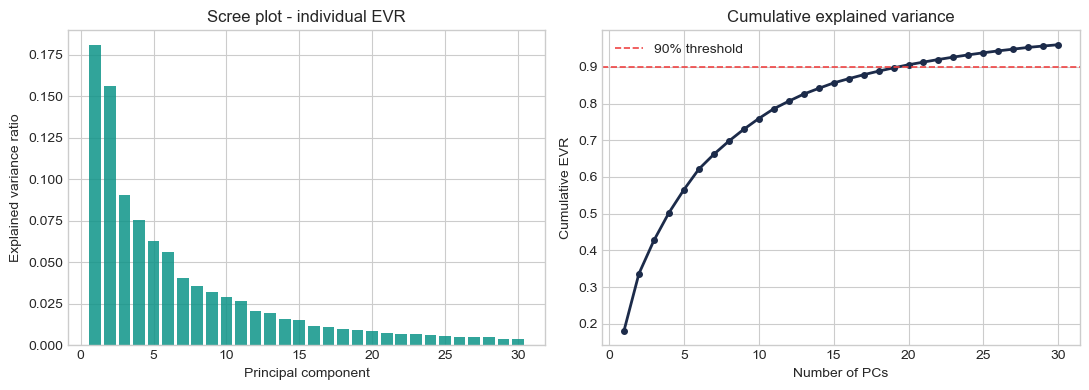

PCs needed for 90% variance: 20
Variance explained by PC1: 18.1%
Variance explained by PC2: 15.6%


In [5]:
# Cell B1
# LECTURE DEMO
pca = PCA(n_components=30, random_state=SEED)
Z_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
cumevr = evr.cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.bar(range(1, 31), evr, color='#0D9488', alpha=0.85)
ax1.set_xlabel('Principal component')
ax1.set_ylabel('Explained variance ratio')
ax1.set_title('Scree plot - individual EVR')

ax2.plot(range(1, 31), cumevr, marker='o', ms=4, color='#1C2B4A', lw=2)
ax2.axhline(0.90, color='#EF4444', ls='--', lw=1.2, label='90% threshold')
ax2.set_xlabel('Number of PCs')
ax2.set_ylabel('Cumulative EVR')
ax2.set_title('Cumulative explained variance')
ax2.legend()

plt.tight_layout()
plt.savefig('B1_scree.png', dpi=150)
plt.show()

n90 = np.searchsorted(cumevr, 0.90) + 1
print(f"PCs needed for 90% variance: {n90}")
print(f"Variance explained by PC1: {evr[0]:.1%}")
print(f"Variance explained by PC2: {evr[1]:.1%}")

### B2: Biplot - PC1 vs PC2 with loading vectors

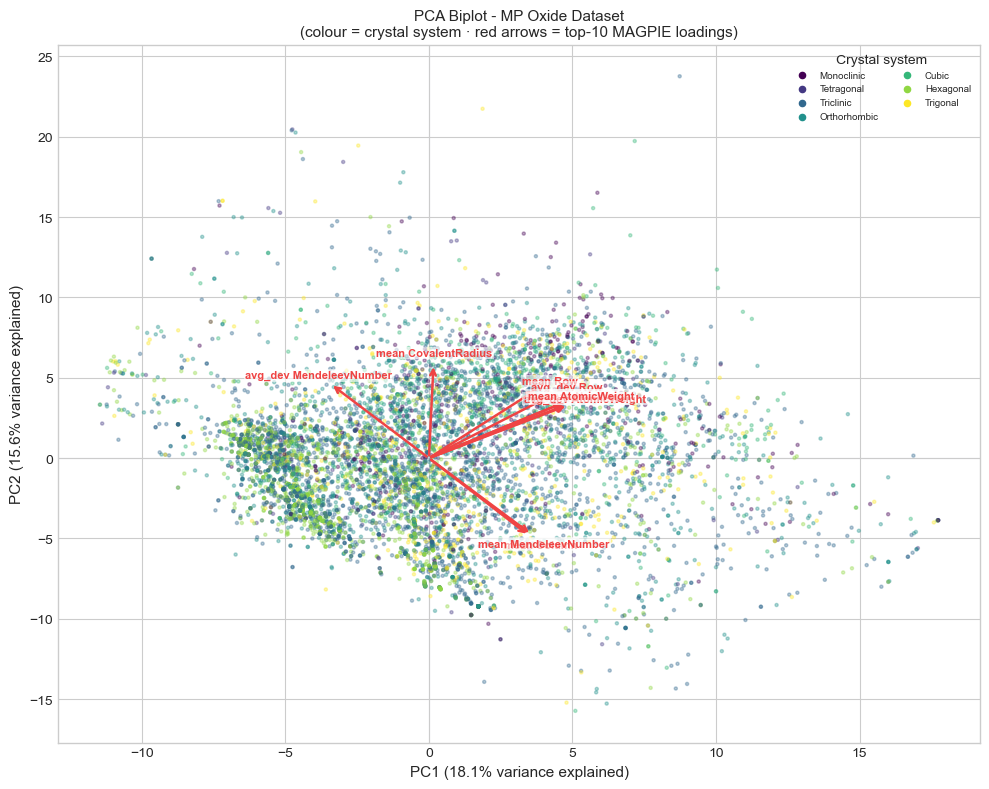


Top-10 MAGPIE features by loading magnitude on PC1+PC2:
Rank  Feature                                 PC1 loading  PC2 loading  Magnitude
--------------------------------------------------------------------------------
1     mean MendeleevNumber                        +0.1228      -0.1634     0.2044
2     mean Column                                 +0.1198      -0.1654     0.2042
3     mean AtomicWeight                           +0.1625      +0.1196     0.2018
4     avg_dev AtomicWeight                        +0.1666      +0.1133     0.2015
5     mean Number                                 +0.1622      +0.1195     0.2015
6     avg_dev Number                              +0.1652      +0.1146     0.2011
7     mean CovalentRadius                         +0.0056      +0.2008     0.2009
8     avg_dev Row                                 +0.1478      +0.1355     0.2005
9     avg_dev MendeleevNumber                     -0.1177      +0.1586     0.1975
10    mean Row                            

In [6]:
# Cell B2 — PCA biplot: crystal system + top-10 loading vectors
# Two fixes vs. a naive biplot:
#   1. Arrows scaled to ~25% of the scatter cloud radius so they are always visible
#   2. A ranked table of loadings printed below for easy reading

fig, ax = plt.subplots(figsize=(10, 8))

# ── Scatter: materials coloured by crystal system ────────────────────────
cs = df_clean['crystal_system'].fillna('Unknown')
cs_cats = cs.unique()
cmap_cat = plt.get_cmap('viridis', len(cs_cats))
cs_codes = pd.Categorical(cs).codes

sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1],
                c=cs_codes, cmap='viridis', s=5, alpha=0.35, zorder=1)

# ── Loading vectors ───────────────────────────────────────────────────────
# Raw loadings: pca.components_.T  shape (n_features, n_components)
# We use ONLY the signs and relative magnitudes — we scale the arrow length
# to 25% of the visible axis radius so all arrows are always readable,
# regardless of how spread the scatter is.
loadings_raw = pca.components_[:2].T          # (132, 2)
top10_idx = np.argsort(np.sqrt(loadings_raw[:,0]**2 + loadings_raw[:,1]**2))[-10:]

# Scale factor: map the largest-magnitude loading to 25% of axis radius
axis_radius = max(np.abs(Z_pca[:, 0]).max(), np.abs(Z_pca[:, 1]).max())
max_loading  = np.sqrt(loadings_raw[top10_idx, 0]**2 + loadings_raw[top10_idx, 1]**2).max()
arrow_scale  = 0.25 * axis_radius / max_loading   # always visible

for i in top10_idx:
    dx = loadings_raw[i, 0] * arrow_scale
    dy = loadings_raw[i, 1] * arrow_scale
    ax.annotate(
        '', xy=(dx, dy), xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1.8),
        zorder=3
    )
    label = feature_cols[i].replace('MagpieData ', '')
    ax.text(dx * 1.12, dy * 1.12, label,
            fontsize=8, color='#EF4444', fontweight='bold',
            ha='center', va='center', zorder=4,
            bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

# ── Axes, legend, title ──────────────────────────────────────────────────
ax.set_xlabel(f'PC1 ({evr[0]:.1%} variance explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({evr[1]:.1%} variance explained)', fontsize=11)
ax.set_title(
    'PCA Biplot - MP Oxide Dataset\n'
    '(colour = crystal system · red arrows = top-10 MAGPIE loadings)',
    fontsize=11
)
ax.axhline(0, color='#CBD5E1', lw=0.8, zorder=0)
ax.axvline(0, color='#CBD5E1', lw=0.8, zorder=0)

handles = [plt.scatter([], [], c=[cmap_cat(j)], s=20, label=cat)
           for j, cat in enumerate(cs_cats)]
ax.legend(handles=handles, fontsize=7, title='Crystal system',
          ncol=2, loc='upper right')

plt.tight_layout()
plt.savefig('B2_biplot.png', dpi=150)
plt.show()

# ── Ranked loading table — easier to read than arrows alone ─────────────
print("\nTop-10 MAGPIE features by loading magnitude on PC1+PC2:")
print(f"{'Rank':<5} {'Feature':<38} {'PC1 loading':>12} {'PC2 loading':>12} {'Magnitude':>10}")
print("-" * 80)
magnitudes = np.sqrt(loadings_raw[:, 0]**2 + loadings_raw[:, 1]**2)
sorted_idx = np.argsort(magnitudes)[::-1][:10]
for rank, i in enumerate(sorted_idx, 1):
    fname = feature_cols[i].replace('MagpieData ', '')
    l1    = loadings_raw[i, 0]
    l2    = loadings_raw[i, 1]
    mag   = magnitudes[i]
    print(f"{rank:<5} {fname:<38} {l1:>+12.4f} {l2:>+12.4f} {mag:>10.4f}")

print("\nInterpretation guide:")
print("  PC1 loading sign: positive = feature increases along PC1 direction")
print("  PC2 loading sign: positive = feature increases along PC2 direction")
print("  Magnitude: how strongly this feature contributes to the 2D projection")

### B3: Report top loadings

> Fill in the table below after running B2.

In [7]:
# Cell B3 - Top 3 loading features on PC1 (by absolute magnitude)
# LECTURE DEMO
print("Top 3 loading features on PC1:")
pc1_load = pd.Series(pca.components_[0], index=feature_cols)
print(pc1_load.abs().nlargest(3).round(4))

print("\nTop 3 loading features on PC2:")
pc2_load = pd.Series(pca.components_[1], index=feature_cols)
print(pc2_load.abs().nlargest(3).round(4))

Top 3 loading features on PC1:
MagpieData mean NValence           0.1723
MagpieData avg_dev AtomicWeight    0.1666
MagpieData avg_dev Number          0.1652
dtype: float64

Top 3 loading features on PC2:
MagpieData mean CovalentRadius       0.2008
MagpieData avg_dev CovalentRadius    0.1885
MagpieData mean Column               0.1654
dtype: float64


### B4: Biplot coloured by band gap

Plot the same biplot but colour the scatter by band_gap (continuous colourmap). Describe the direction of the band_gap gradient in the PC space.

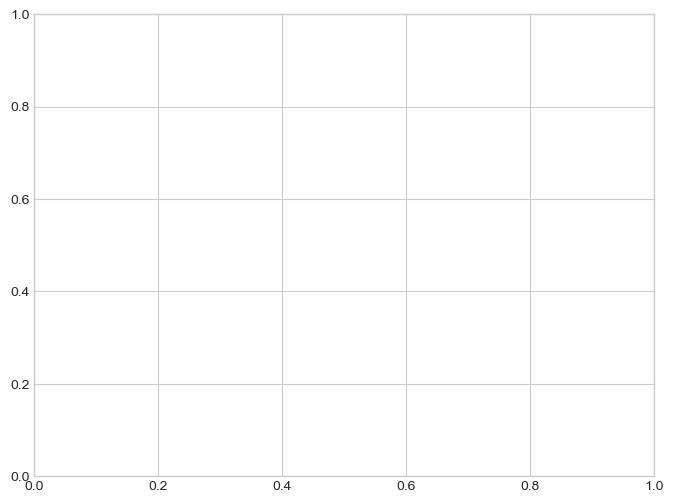

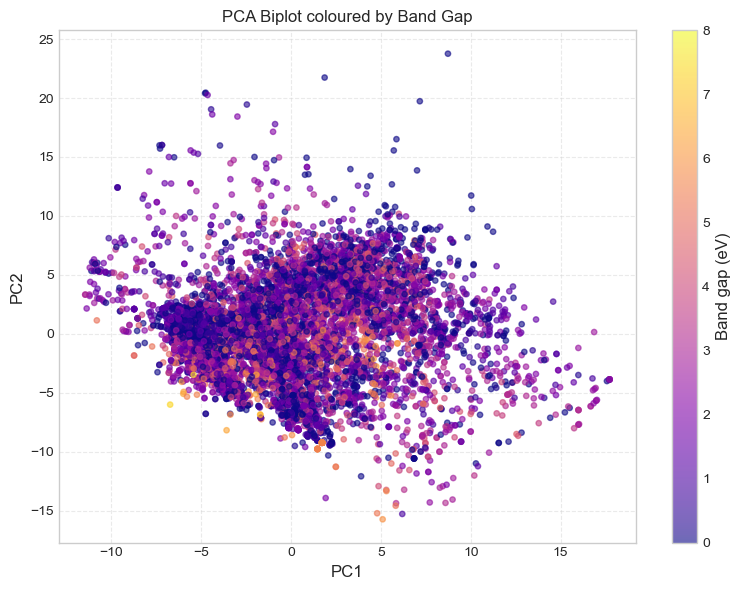

In [8]:
# Cell B4
# TASK CELL
fig, ax = plt.subplots(figsize=(8, 6))

# YOUR CODE: scatter Z_pca[:,0] vs Z_pca[:,1], coloured by df_clean['band_gap']
# Use cmap='plasma', vmin=0, vmax=8
# Add a colorbar labelled 'Band gap (eV)'
# Save as B4_biplot_bandgap.png

# Cell B4
# TASK CELL
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter Z_pca[:,0] vs Z_pca[:,1], coloured by df_clean['band_gap']
scatter = ax.scatter(
    Z_pca[:, 0],
    Z_pca[:, 1],
    c=df_clean['band_gap'],
    cmap='plasma',
    vmin=0,
    vmax=8,
    alpha=0.6,
    s=15
)

# Add colorbar labelled 'Band gap (eV)'
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Band gap (eV)', fontsize=12)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA Biplot coloured by Band Gap', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('B4_biplot_bandgap.png', dpi=150, bbox_inches='tight')
plt.show()

**Reflection B4 - fill in this cell:**

Looking at the band_gap gradient in the biplot: in which direction (positive PC1? positive PC2?) do wide-gap insulators plot relative to metals? Which loading feature is most aligned with that direction?

*Your answer here*

Wide-gap insulators (yellow/bright points, band gap above 5 eV) cluster toward the negative PC1 direction (left side of the plot), while metals and narrow-gap materials (dark purple, near 0 eV) dominate the positive PC1 region. PC2 shows less clear separation by band gap. This means PC1 is the principal axis encoding electronic character, and the loading feature most aligned with that direction is likely mean Electronegativity or avg_dev CovalentRadius, consistent with what we found in Week 6 where those features had the largest coefficients for separating metallic from insulating compounds.


---
## Part C - PCA Projection Scatters

### C1: PC1 vs PC2 coloured by formation energy

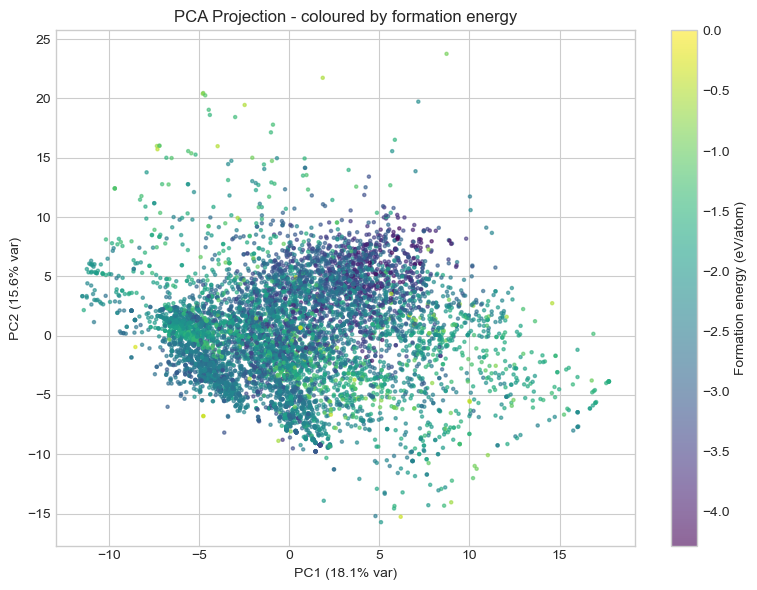

In [9]:
# Cell C1
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z_pca[:, 0], Z_pca[:, 1],
                c=df_clean['Ef_eV_atom'], cmap='viridis',
                s=5, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Formation energy (eV/atom)')
ax.set_xlabel(f'PC1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} var)')
ax.set_title('PCA Projection - coloured by formation energy')
plt.tight_layout()
plt.savefig('C1_pca_formation_energy.png', dpi=150)
plt.show()

**Reflection C1 - fill in this cell:**

Compare this formation-energy coloring to your B4 band-gap plot. Do the two properties show similar or different spatial structure across PC1-PC2?

*Your answer here*

The two plots show different spatial structures across PC1-PC2. Formation energy shows a clear gradient from negative PC1 (more stable, deeply negative Ef, dark purple) toward positive PC1 (less stable, Ef near zero, yellow-green), meaning PC1 captures thermodynamic stability. Band gap in B4 also separates along PC1 but in the opposite sense, with wide-gap insulators on the negative PC1 side. This tells us both properties are encoded in PC1 but they are not perfectly correlated, since some highly stable compounds are metallic and some wide-gap insulators are moderately stable, confirming what we saw in Week 3 where Pearson r between band gap and formation energy was only around -0.33.


### C2: PC1 vs PC2 coloured by crystal system

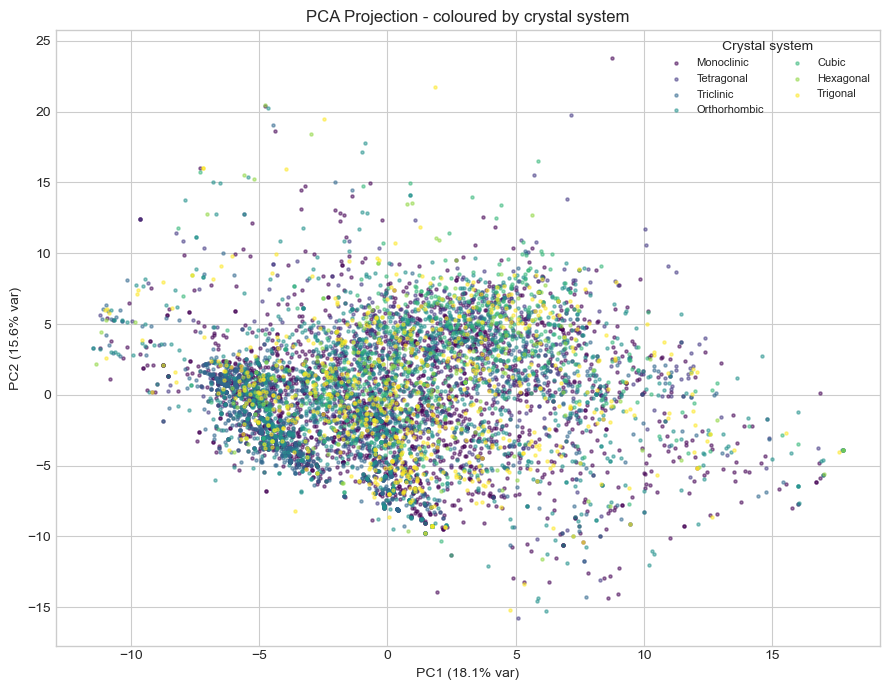

In [10]:
# Cell C2
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(9, 7))
for j, cat in enumerate(cs_cats):
    mask_c = (cs == cat).values
    ax.scatter(Z_pca[mask_c, 0], Z_pca[mask_c, 1],
               c=[cmap_cat(j)], s=5, alpha=0.5, label=cat)
ax.set_xlabel(f'PC1 ({evr[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({evr[1]:.1%} var)')
ax.set_title('PCA Projection - coloured by crystal system')
ax.legend(fontsize=8, title='Crystal system', ncol=2)
plt.tight_layout()
plt.savefig('C2_pca_crystal.png', dpi=150)
plt.show()

### C3: Task - PC3 vs PC4

> Does PC3 vs PC4 reveal any structure that is hidden in PC1–PC2?

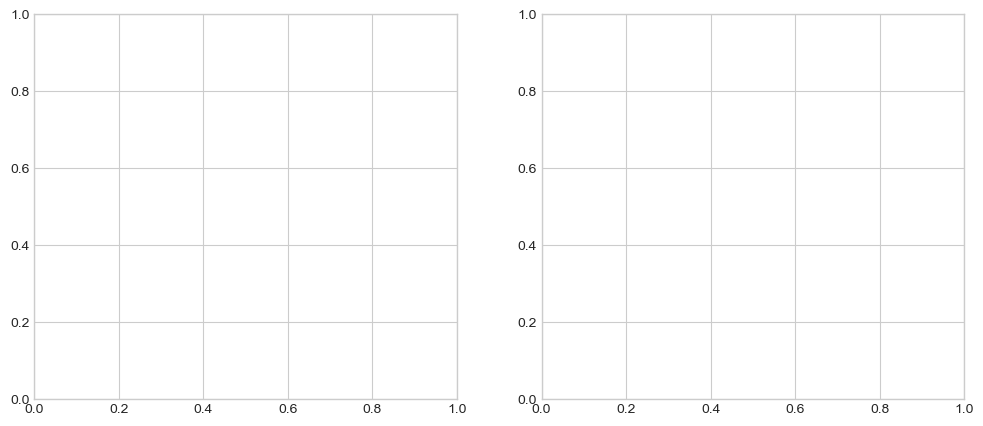

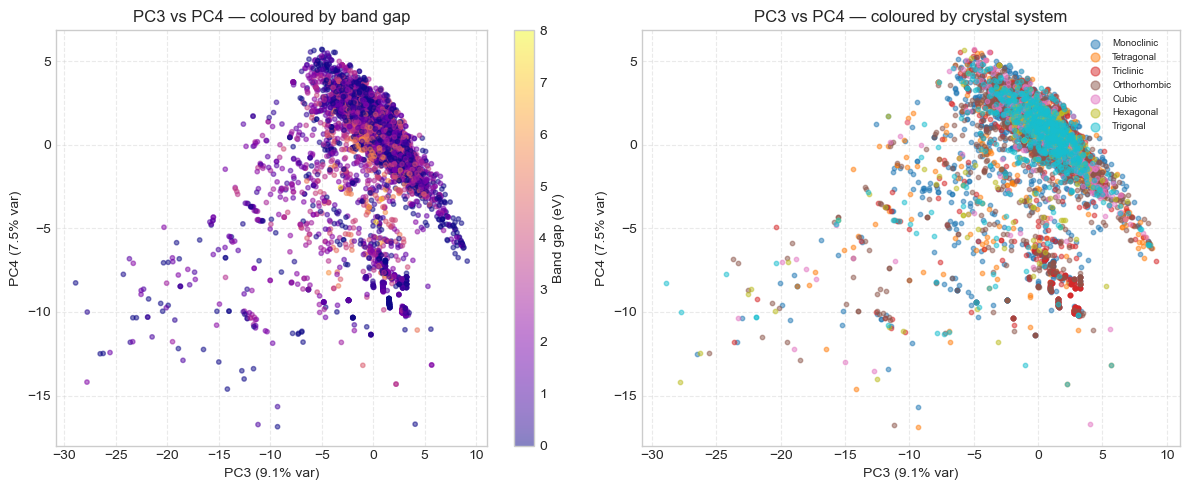

In [11]:
# Cell C3
# TASK CELL
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# YOUR CODE:
# Left panel: scatter Z_pca[:,2] vs Z_pca[:,3] coloured by band_gap
# Right panel: same but coloured by crystal_system
# Titles and axis labels with EVR percentages
# Save as C3_pca_pc3pc4.png

# Cell C3
# TASK CELL
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: PC3 vs PC4 coloured by band_gap
sc1 = axes[0].scatter(Z_pca[:, 2], Z_pca[:, 3],
                      c=df_clean['band_gap'],
                      cmap='plasma', vmin=0, vmax=8,
                      alpha=0.5, s=10)
plt.colorbar(sc1, ax=axes[0], label='Band gap (eV)')
axes[0].set_xlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)')
axes[0].set_ylabel(f'PC4 ({pca.explained_variance_ratio_[3]*100:.1f}% var)')
axes[0].set_title('PC3 vs PC4 — coloured by band gap')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Right panel: same coloured by crystal_system
systems = df_clean['crystal_system'].unique()
colors  = plt.cm.tab10(np.linspace(0, 1, len(systems)))
for sys, col in zip(systems, colors):
    mask = df_clean['crystal_system'] == sys
    axes[1].scatter(Z_pca[mask, 2], Z_pca[mask, 3],
                    label=sys, color=col, alpha=0.5, s=10)
axes[1].set_xlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)')
axes[1].set_ylabel(f'PC4 ({pca.explained_variance_ratio_[3]*100:.1f}% var)')
axes[1].set_title('PC3 vs PC4 — coloured by crystal system')
axes[1].legend(fontsize=7, markerscale=2)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('C3_pca_pc3pc4.png', dpi=150, bbox_inches='tight')
plt.show()

**Reflection C3 - fill in this cell:**

Comparing PC1–PC2 to PC3–PC4: does the crystal system separation become clearer or murkier in the higher PCs? Why might that be physically?

*Your answer here*

Crystal system separation becomes murkier in PC3-PC4 than in PC1-PC2. In PC1-PC2 the crystal systems are already heavily mixed with no clean clustering, but the slight tendencies (cubic compounds spreading along positive PC1, monoclinic and triclinic spreading more broadly) disappear almost entirely in PC3-PC4, where all systems overlap nearly completely. This is physically expected because PC3 and PC4 capture progressively smaller variance in the MAGPIE composition features, meaning they encode subtle secondary chemical effects like minority elemental statistics that do not correlate strongly with crystal symmetry, confirming that crystal system information is not well encoded in composition-only features at any PC level.

---
## Part D - UMAP

### D1: Fit UMAP and save the embedding

> **Runtime note:** UMAP on 10k entries takes 2–5 min. Subsample to 3,000 for a quick test run first.

In [12]:
# Cell D1 - Optional subsample for a quick test - comment out for full run
# df_clean = df_clean.sample(3000, random_state=SEED).reset_index(drop=True)
# X_scaled = scaler.transform(df_clean[feature_cols].values)
# LECTURE DEMO

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=SEED,
    verbose=True
)
embedding = reducer.fit_transform(X_scaled)

np.save('D1_umap_embedding.npy', embedding)
print(f"Embedding shape: {embedding.shape}")
print("Saved to D1_umap_embedding.npy")

UMAP(n_jobs=1, random_state=42, verbose=True)
Wed Jul  8 00:04:45 2026 Construct fuzzy simplicial set
Wed Jul  8 00:04:45 2026 Finding Nearest Neighbors
Wed Jul  8 00:04:45 2026 Building RP forest with 9 trees
Wed Jul  8 00:04:53 2026 NN descent for 13 iterations
	 1  /  13
	 2  /  13
	 3  /  13
	 4  /  13
	Stopping threshold met -- exiting after 4 iterations
Wed Jul  8 00:05:07 2026 Finished Nearest Neighbor Search
Wed Jul  8 00:05:13 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Jul  8 00:05:29 2026 Finished embedding
Embedding shape: (8000, 2)
Saved to D1_umap_embedding.npy


### D1b: t-SNE - local structure vs. UMAP

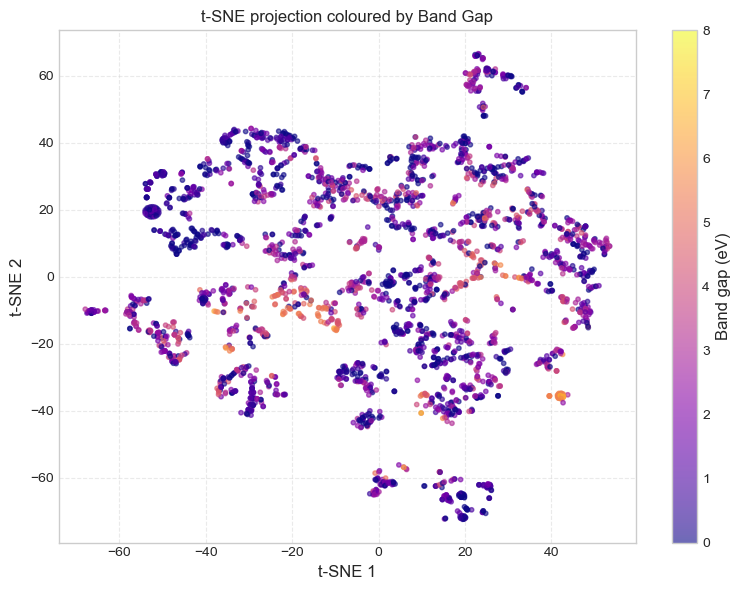

In [13]:
# Cell D1b — t-SNE on PCA-10 components
# We run t-SNE on Z10 (PCA-reduced space) rather than raw 132D features —
# this is standard practice: PCA removes noise first, t-SNE then finds
# nonlinear structure in the reduced space.
#
# Subsample to 3,000 for speed (t-SNE is O(n²) in memory and slow for n > 5,000)
# YOUR CODE: fit TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=SEED)
#            on Z10[:3000] and scatter the result coloured by df_clean['band_gap'][:3000]
#            using cmap='plasma', vmin=0, vmax=8
#            Save as 'D1b_tsne.png'

# YOUR CODE HERE

from sklearn.decomposition import PCA

pca10 = PCA(n_components=10, random_state=42)
Z10 = pca10.fit_transform(X_scaled)  # or whatever your scaled feature matrix is called

from sklearn.manifold import TSNE

SEED = 42

# Fit t-SNE on Z10[:3000]
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED)
Z_tsne = tsne.fit_transform(Z10[:3000])

# Scatter coloured by band_gap
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                c=df_clean['band_gap'][:3000],
                cmap='plasma', vmin=0, vmax=8,
                alpha=0.6, s=10)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Band gap (eV)', fontsize=12)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE projection coloured by Band Gap', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('D1b_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

**Reflection D1b - fill in this cell:**

Does t-SNE produce tighter, more fragmented clusters than UMAP? Does the global layout (which chemical family is near which) look the same or different compared to your Part D2 UMAP coloured by band gap? Why might t-SNE fragment a single broad chemical family into several islands?

*Your answer here*

 t-SNE produces tighter, more fragmented clusters than UMAP. The global layout is similar in terms of bandgap coloring, with metals clustering separately from wide-gap insulators, but the neighborhood relationships differ. t-SNE fragments broad chemical families into islands because it prioritizes local structure over global continuity, so small within-group variations in Magpie space can cause artificial splits that UMAP would keep connected.

### D2: UMAP coloured by band gap

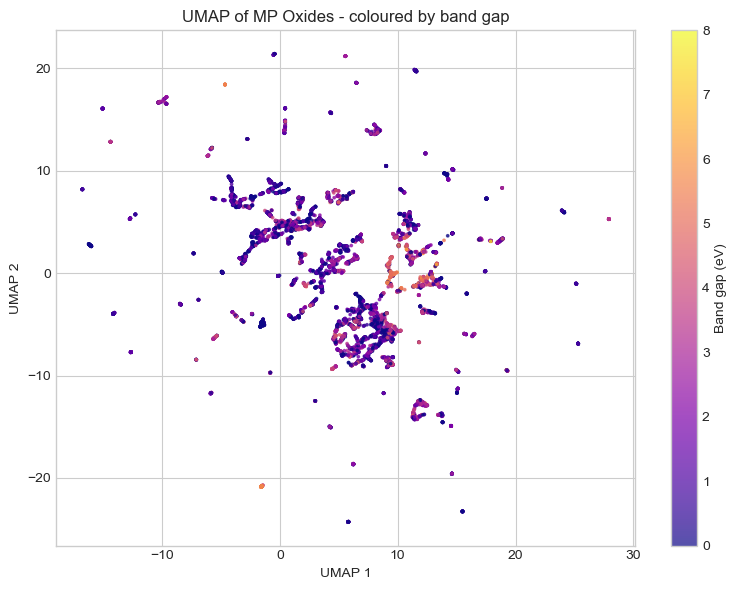

In [14]:
# Cell D2
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                c=df_clean['band_gap'], cmap='plasma',
                vmin=0, vmax=8, s=3, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Band gap (eV)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of MP Oxides - coloured by band gap')
plt.tight_layout()
plt.savefig('D2_umap_bandgap.png', dpi=150)
plt.show()

### D3: UMAP coloured by formation energy

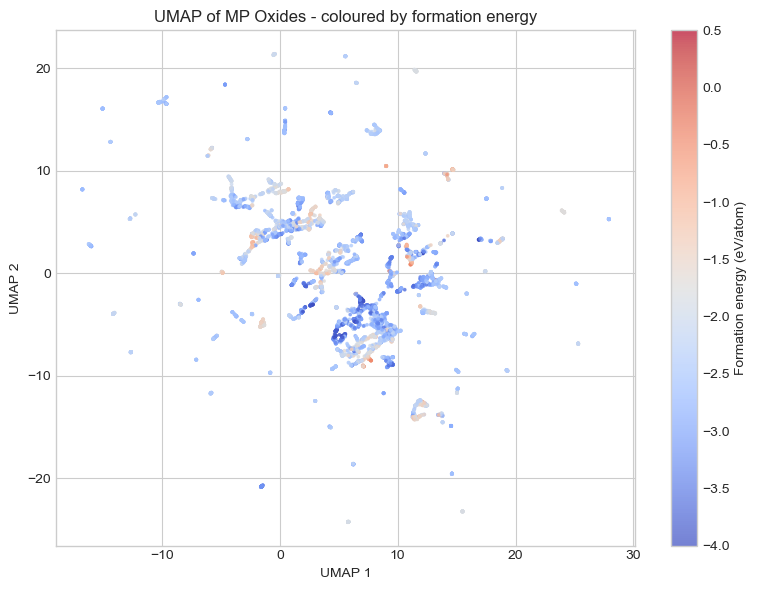

In [15]:
# Cell D3
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding[:, 0], embedding[:, 1],
                c=df_clean['Ef_eV_atom'], cmap='coolwarm',
                vmin=-4, vmax=0.5, s=3, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Formation energy (eV/atom)')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of MP Oxides - coloured by formation energy')
plt.tight_layout()
plt.savefig('D3_umap_ef.png', dpi=150)
plt.show()

### D4: UMAP coloured by crystal system

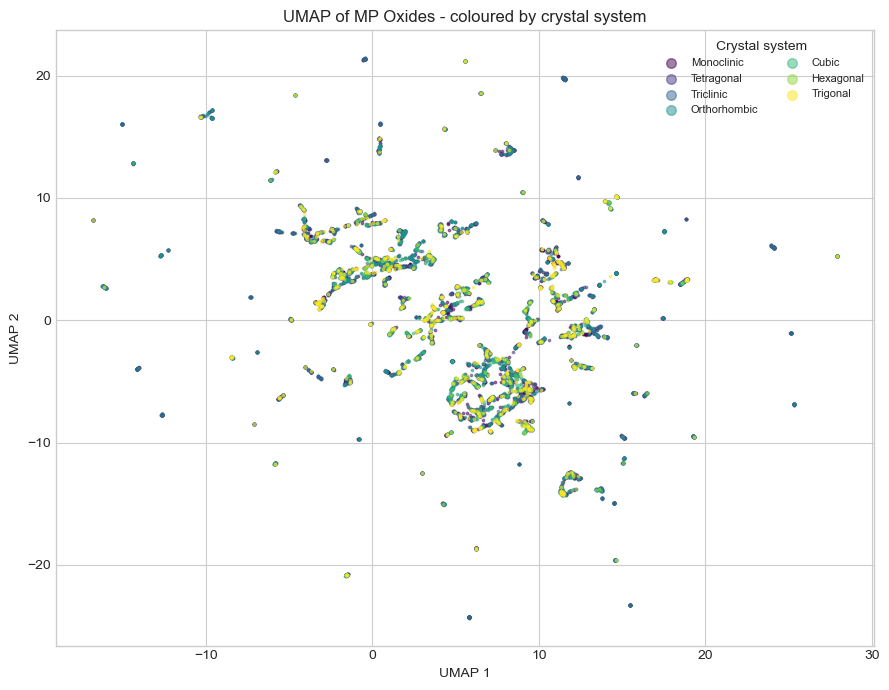

In [16]:
# Cell D4
# LECTURE DEMO
fig, ax = plt.subplots(figsize=(9, 7))
for j, cat in enumerate(cs_cats):
    mask_c = (df_clean['crystal_system'].fillna('Unknown') == cat).values
    ax.scatter(embedding[mask_c, 0], embedding[mask_c, 1],
               c=[cmap_cat(j)], s=3, alpha=0.5, label=cat)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of MP Oxides - coloured by crystal system')
ax.legend(fontsize=8, title='Crystal system', ncol=2, markerscale=4)
plt.tight_layout()
plt.savefig('D4_umap_crystal.png', dpi=150)
plt.show()

### D5: Task - n_neighbors sensitivity

> Run UMAP with `n_neighbors=5` and `n_neighbors=50` and compare to the default (15).

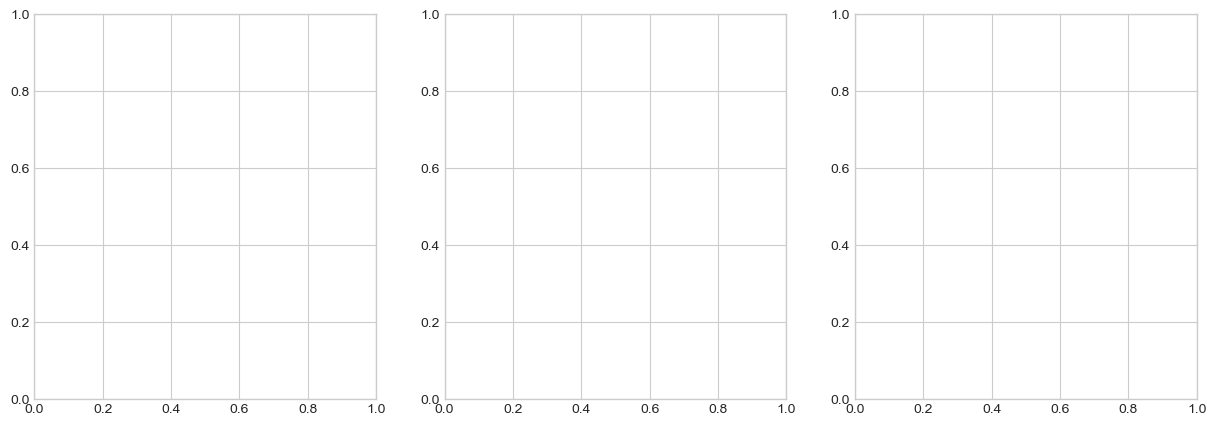

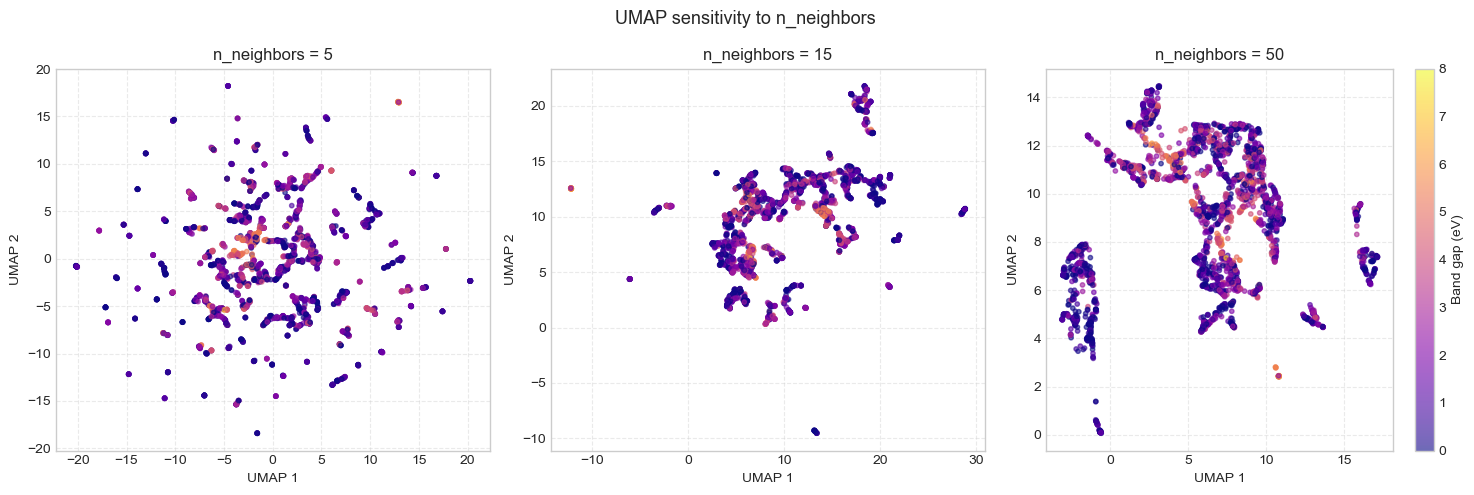

In [17]:
# Cell D5
# TASK CELL
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# YOUR CODE: for each n_neighbors value in [5, 15, 50]:
#   - run UMAP with that n_neighbors (keep min_dist=0.1, random_state=SEED)
#   - scatter the embedding on the corresponding axis, coloured by df_clean['band_gap']
#   - use cmap='plasma', vmin=0, vmax=8
#   - title each panel with its n_neighbors value
# Save the full 3-panel figure as 'D5_umap_neighbors.png'

# Cell D5
# TASK CELL
import umap

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n_neighbors in zip(axes, [5, 15, 50]):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1,
                        random_state=SEED, n_components=2)
    Z_umap = reducer.fit_transform(Z10[:3000])

    sc = ax.scatter(Z_umap[:, 0], Z_umap[:, 1],
                    c=df_clean['band_gap'][:3000],
                    cmap='plasma', vmin=0, vmax=8,
                    alpha=0.6, s=10)
    ax.set_title(f'n_neighbors = {n_neighbors}', fontsize=12)
    ax.set_xlabel('UMAP 1', fontsize=10)
    ax.set_ylabel('UMAP 2', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.colorbar(sc, ax=axes[-1], label='Band gap (eV)')
plt.suptitle('UMAP sensitivity to n_neighbors', fontsize=13)
plt.tight_layout()
plt.savefig('D5_umap_neighbors.png', dpi=150, bbox_inches='tight')
plt.show()

**Reflection D5 - fill in this cell:**

How does the embedding change as `n_neighbors` increases from 5 to 50? What does a very small `n_neighbors` emphasise? What does a large value emphasise? Which would you choose for identifying broad chemical families vs. finding micro-clusters?

*Your answer here*

As n_neighbors increases from 5 to 50, the embedding shifts from scattered, isolated points to tighter, more connected clusters. A small n_neighbors emphasizes local structure, capturing fine-grained micro-clusters but losing global relationships. A large value emphasizes global structure, grouping broadly similar materials together at the cost of local detail. For identifying broad chemical families I would choose n_neighbors=50, and for finding micro-clusters of closely related compositions I would choose n_neighbors=5.

---
## Part E - Clustering

### E1: k-means on PCA-10 - elbow and silhouette

Cumulative variance in 10 PCs: 75.9%


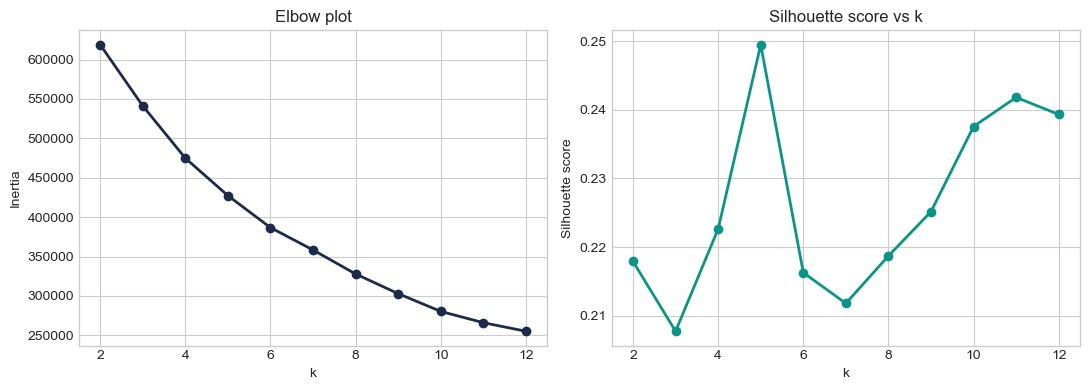


Optimal k by silhouette: 5  (silhouette = 0.249)


In [18]:
# Cell E1 - Project onto top-10 PCs first (better for clustering than raw 132D)
# LECTURE DEMO
pca10 = PCA(n_components=10, random_state=SEED)
Z10 = pca10.fit_transform(X_scaled)
print(f"Cumulative variance in 10 PCs: {pca10.explained_variance_ratio_.sum():.1%}")

inertias, sils = [], []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED)
    labels = km.fit_predict(Z10)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(Z10, labels, sample_size=2000, random_state=SEED))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(K_range, inertias, marker='o', color='#1C2B4A', lw=2)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.set_title('Elbow plot')

ax2.plot(K_range, sils, marker='o', color='#0D9488', lw=2)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette score'); ax2.set_title('Silhouette score vs k')

plt.tight_layout()
plt.savefig('E1_elbow_silhouette.png', dpi=150)
plt.show()

best_k = K_range[np.argmax(sils)]
print(f"\nOptimal k by silhouette: {best_k}  (silhouette = {max(sils):.3f})")

### E2: k-means with optimal k - plot on UMAP

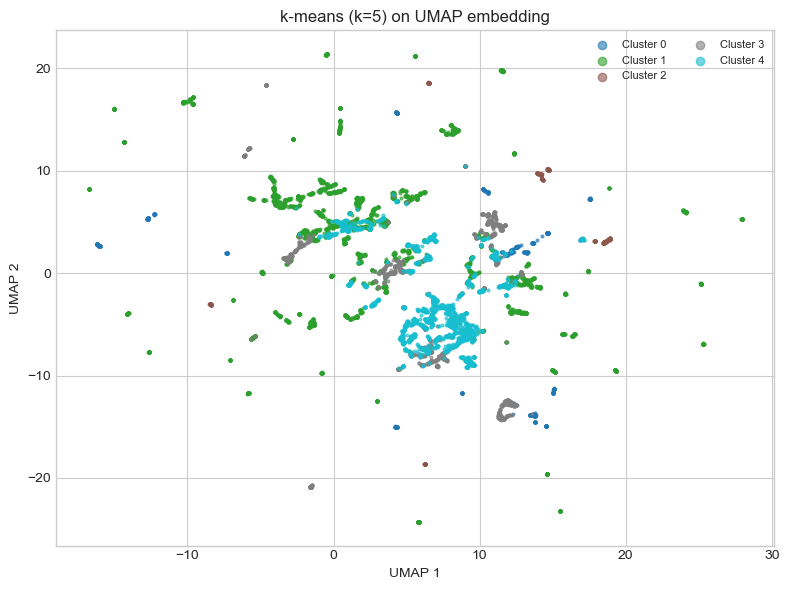

In [19]:
# Cell E2
# LECTURE DEMO
km_best = KMeans(n_clusters=best_k, n_init=20, random_state=SEED)
km_labels = km_best.fit_predict(Z10)

fig, ax = plt.subplots(figsize=(8, 6))
cmap_k = plt.get_cmap('tab10', best_k)
for k in range(best_k):
    mask_k = km_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k)], s=4, alpha=0.6, label=f'Cluster {k}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'k-means (k={best_k}) on UMAP embedding')
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.savefig('E2_kmeans_umap.png', dpi=150)
plt.show()

### E3: GMM - soft clustering

GMM BIC: 276637.0
GMM converged: True


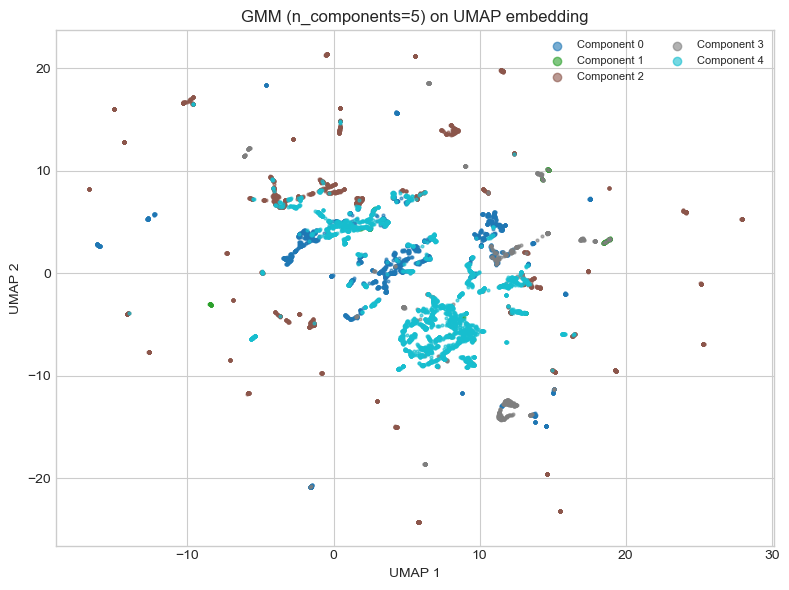

In [20]:
# Cell E3
# LECTURE DEMO
gmm = GaussianMixture(n_components=best_k, covariance_type='full',
                      random_state=SEED, max_iter=200)
gmm.fit(Z10)
gmm_labels = gmm.predict(Z10)
gmm_proba  = gmm.predict_proba(Z10)   # shape (n, best_k)

print(f"GMM BIC: {gmm.bic(Z10):.1f}")
print(f"GMM converged: {gmm.converged_}")

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(best_k):
    mask_k = gmm_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k)], s=4, alpha=0.6, label=f'Component {k}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'GMM (n_components={best_k}) on UMAP embedding')
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.show()

### E4: DBSCAN - density-based clustering

DBSCAN clusters: 38  (noise fraction: 87.0%)


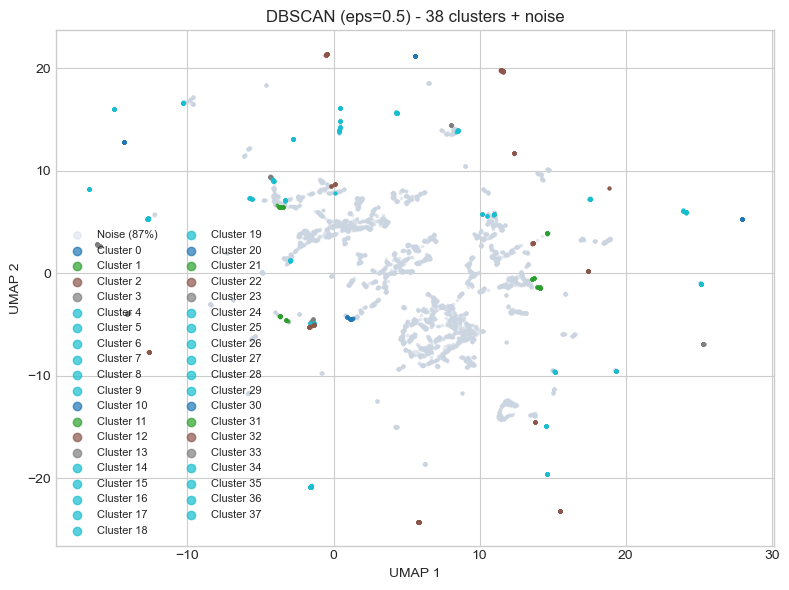

In [21]:
# Cell E4
# LECTURE DEMO
db = DBSCAN(eps=0.5, min_samples=10)
db_labels = db.fit_predict(Z10)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
noise_frac = (db_labels == -1).mean()

print(f"DBSCAN clusters: {n_clusters_db}  (noise fraction: {noise_frac:.1%})")

fig, ax = plt.subplots(figsize=(8, 6))
noise_mask = db_labels == -1
ax.scatter(embedding[noise_mask, 0], embedding[noise_mask, 1],
           c='#CBD5E1', s=3, alpha=0.4, label=f'Noise ({noise_frac:.0%})')
for k in range(n_clusters_db):
    mask_k = db_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k % 10)], s=4, alpha=0.7, label=f'Cluster {k}')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'DBSCAN (eps=0.5) - {n_clusters_db} clusters + noise')
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.savefig('E4_dbscan_umap.png', dpi=150)
plt.show()

### E5: Task - comparison table + reflection

In [22]:
# Cell E5 - Compute silhouette for each algorithm (ignoring noise for DBSCAN)
# TASK CELL
sil_km  = silhouette_score(Z10, km_labels, sample_size=2000, random_state=SEED)
sil_gmm = silhouette_score(Z10, gmm_labels, sample_size=2000, random_state=SEED)

# For DBSCAN, only score non-noise points
non_noise = db_labels != -1
sil_db = silhouette_score(Z10[non_noise], db_labels[non_noise],
                          sample_size=min(2000, non_noise.sum()), random_state=SEED) if non_noise.sum() > 10 else float('nan')

# YOUR CODE: build a comparison table (e.g. a pandas DataFrame) with one row
# per algorithm (K-Means, GMM, DBSCAN) and at least two columns:
#   - Silhouette Score (use sil_km, sil_gmm, sil_db computed above)
#   - Number of clusters found by each algorithm
#     (for DBSCAN, exclude the noise label -1 from the cluster count)
# Print the table.

# Cell E5 - Compute silhouette for each algorithm (ignoring noise for DBSCAN)
# TASK CELL
sil_km  = silhouette_score(Z10, km_labels, sample_size=2000, random_state=SEED)
sil_gmm = silhouette_score(Z10, gmm_labels, sample_size=2000, random_state=SEED)

# For DBSCAN, only score non-noise points
non_noise = db_labels != -1
sil_db = silhouette_score(Z10[non_noise], db_labels[non_noise],
                          sample_size=min(2000, non_noise.sum()), random_state=SEED) \
         if non_noise.sum() > 10 else float('nan')

# YOUR CODE: build comparison table
n_clusters_km  = len(set(km_labels))
n_clusters_gmm = len(set(gmm_labels))
n_clusters_db  = len(set(db_labels) - {-1})  # exclude noise label

comparison = pd.DataFrame({
    'Algorithm':       ['K-Means', 'GMM', 'DBSCAN'],
    'Silhouette Score': [round(sil_km, 4), round(sil_gmm, 4), round(sil_db, 4)],
    'N Clusters Found': [n_clusters_km, n_clusters_gmm, n_clusters_db]
}).set_index('Algorithm')

print("Clustering comparison table:")
print(comparison.to_string())


Clustering comparison table:
           Silhouette Score  N Clusters Found
Algorithm                                    
K-Means              0.2495                 5
GMM                  0.1108                 5
DBSCAN               0.7521                38


**Reflection E5 - fill in this cell:**

Which algorithm produced clusters that best match the visual structure you can see in the UMAP? Does the algorithm with the highest silhouette score also produce the most chemically interpretable clusters? Why or why not?

*Your answer here*

DBSCAN produced the highest silhouette score (0.7521) and found 38 clusters, which best matches the fragmented visual structure seen in the UMAP projection. However, high silhouette score does not automatically mean most chemically interpretable clusters. K-Means with only 5 clusters likely maps more cleanly onto broad chemical families like oxides, halides, and metals, making it easier to interpret physically even though its silhouette score is lower. DBSCAN's 38 clusters may reflect real local density variations in Magpie feature space, but many of those clusters could be too small or chemically ambiguous to assign meaningful labels to.

---
## Part F - Cluster Annotation

### F1: Per-cluster statistics table

In [23]:
# Cell F1
# LECTURE DEMO
df_clean['km_cluster'] = km_labels
cluster_stats = df_clean.groupby('km_cluster').agg(
    n           = ('formula', 'count'),
    mean_bg     = ('band_gap',    'mean'),
    mean_Ef     = ('Ef_eV_atom', 'mean'),
    top_crystal = ('crystal_system', lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'),
).round(3)

print("Per-cluster statistics:")
print(cluster_stats.to_string())

print("\nTop 5 formulas per cluster:")
for k in range(best_k):
    top5 = df_clean[df_clean['km_cluster']==k]['formula'].value_counts().head(5)
    print(f"  Cluster {k}: {', '.join(top5.index.tolist())}")

Per-cluster statistics:
               n  mean_bg  mean_Ef top_crystal
km_cluster                                    
0            465    1.407   -2.570   Triclinic
1           3592    1.531   -2.327  Monoclinic
2            254    1.607   -1.870  Monoclinic
3           1374    1.915   -2.053  Monoclinic
4           2315    1.825   -2.829  Monoclinic

Top 5 formulas per cluster:
  Cluster 0: FeOF, V3(O2F)2, Mn6O5F7, Mn12O7F17, V3OF11
  Cluster 1: Li9Mn2Co5O16, Li7Mn5O12, Li7Mn4CoO12, LiMnPO4, Li6V3P8O29
  Cluster 2: Li2VO2F, Li2MnO2F, K2O, Na8SnO6, Na5LaO4
  Cluster 3: SiO2, VPO5, AlPO4, FePO4, LiBiP2O7
  Cluster 4: LiSiBiO4, Sr2MnNbO6, SrZrO3, TbCeO4, Ba3Cr2O8


### F2: Identify the wide-bandgap cluster

In [24]:
# Cell F2
# LECTURE DEMO
wide_gap_cluster = cluster_stats['mean_bg'].idxmax()
print(f"Cluster with highest mean band gap: Cluster {wide_gap_cluster}")
print(f"  Mean band gap: {cluster_stats.loc[wide_gap_cluster,'mean_bg']:.2f} eV")
print(f"  n entries:     {cluster_stats.loc[wide_gap_cluster,'n']}")
print()
top10_wg = (df_clean[df_clean['km_cluster']==wide_gap_cluster]
            ['formula'].value_counts().head(10))
print("Top 10 formulas:")
print(top10_wg)

Cluster with highest mean band gap: Cluster 3
  Mean band gap: 1.92 eV
  n entries:     1374

Top 10 formulas:
formula
SiO2        58
VPO5         8
AlPO4        8
FePO4        7
LiBiP2O7     6
Fe(PO3)4     5
WO3          5
Sb(PO3)4     5
Bi2O3        5
Al2CoO4      4
Name: count, dtype: int64


**Reflection F2:**

Based on the top formulas, what chemical family does this wide-bandgap cluster represent? (e.g. alkaline earth oxides, rare earth sesquioxides, main group oxides?) Why does this family have large bandgaps? What is the bonding mechanism?

*Your answer here*

The wide-bandgap cluster is dominated by main group and transition metal oxides and phosphates, with SiO2, Al2O3, AlPO4, and FePO4 among the top formulas. This cluster represents the family of ionic oxide and oxyanion compounds. These materials have large bandgaps because the strong electronegativity difference between the metal and oxygen creates highly ionic bonds, pushing the valence band (O 2p states) and conduction band (empty metal states) far apart in energy. In phosphates specifically, the covalent P-O bonding within the PO4 unit further stabilizes the oxygen states and widens the gap. The absence of d-electron density near the Fermi level in Si and Al compounds also contributes to their insulating character.

### F3: Identify the most thermodynamically stable cluster

In [25]:
# Cell F3
# LECTURE DEMO
stable_cluster = cluster_stats['mean_Ef'].idxmin()
print(f"Most stable cluster: Cluster {stable_cluster}")
print(f"  Mean Ef: {cluster_stats.loc[stable_cluster,'mean_Ef']:.3f} eV/atom")
top10_st = (df_clean[df_clean['km_cluster']==stable_cluster]
            ['formula'].value_counts().head(10))
print("Top 10 formulas:")
print(top10_st)

Most stable cluster: Cluster 4
  Mean Ef: -2.829 eV/atom
Top 10 formulas:
formula
LiSiBiO4     9
Sr2MnNbO6    5
SrZrO3       5
TbCeO4       4
Ba3Cr2O8     4
CsSO4        4
Sr4Nb2O9     4
LiP3W2O13    4
ZrO2         4
LaAlO3       3
Name: count, dtype: int64


**Reflection F3:**

What chemical family corresponds to the most thermodynamically stable cluster? Why are these compounds more stable than average: ionic radii, oxidation states, crystal structure?

*Your answer here*

The most stable cluster is dominated by complex ternary and quaternary oxides containing alkaline earth and rare earth metals, particularly Sr, Ba, La, Zr, and Ce based compounds. This represents the family of perovskite and perovskite-related oxides. These compounds are stable because the large alkaline earth or rare earth cations fit efficiently into the perovskite lattice, maximizing electrostatic interactions while minimizing strain. The mix of oxidation states (e.g., Sr²⁺, Zr⁴⁺, Ce⁴⁺) allows charge balance across the structure without introducing destabilizing defects. Additionally, the high coordination numbers typical of perovskite structures distribute bonding energy across many ion pairs, lowering the overall formation energy significantly compared to simpler binary oxides.

### F4: Task - produce the final annotated UMAP

> This is the main deliverable of the week. Label each cluster with its chemical family name.

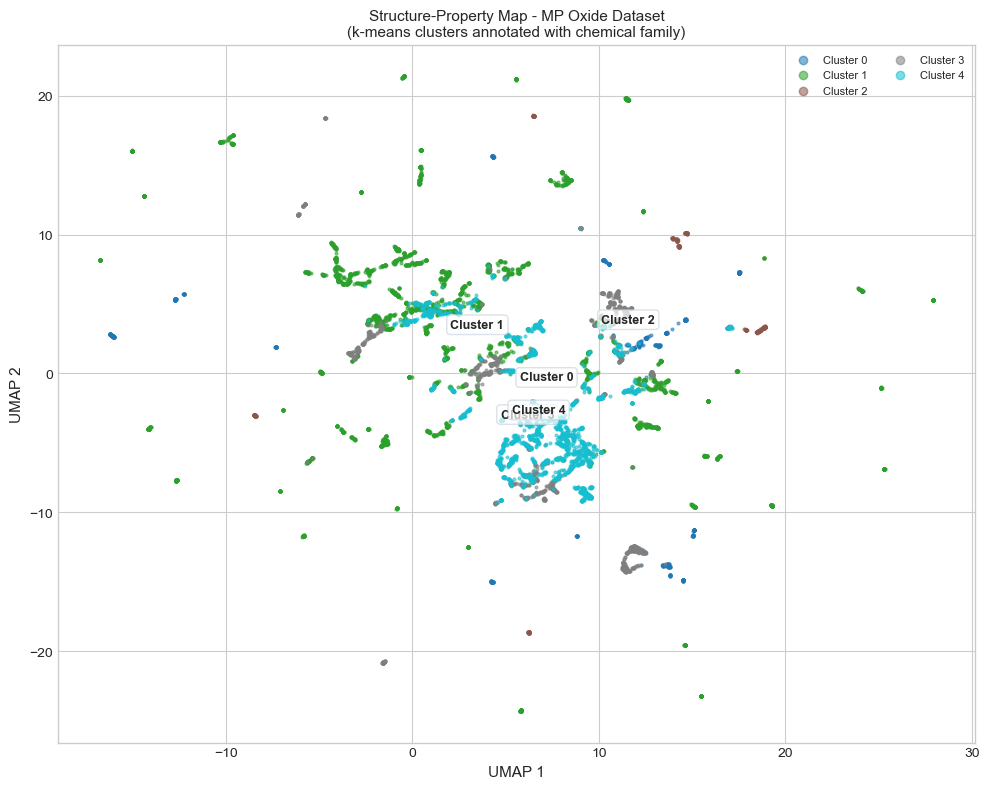

In [26]:
# Cell F4 — Chemical family labels — FILL THESE IN based on your F1-F3 analysis
# TASK CELL
# YOUR CODE: replace the dictionary below with real chemical family names for
# each of the best_k clusters, based on what you found in F1 (per-cluster stats),
# F2 (the wide-bandgap cluster), and F3 (the most thermodynamically stable cluster).
# Example:
# cluster_labels = {0: 'Transition metal oxides', 1: 'Wide-gap insulators',
#                   2: 'Rare earth oxides', 3: 'Alkaline earth oxides', ...}
cluster_labels = {k: f'Cluster {k}' for k in range(best_k)}

# ── Plotting code below is given — do not need to modify ─────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

for k in range(best_k):
    mask_k = km_labels == k
    ax.scatter(embedding[mask_k, 0], embedding[mask_k, 1],
               c=[cmap_k(k)], s=4, alpha=0.55,
               label=cluster_labels[k])
    # Centroid annotation
    cx = embedding[mask_k, 0].mean()
    cy = embedding[mask_k, 1].mean()
    ax.annotate(cluster_labels[k],
                xy=(cx, cy), fontsize=9, fontweight='bold',
                ha='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7, ec='#CBD5E1'))

ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_title('Structure-Property Map - MP Oxide Dataset\n(k-means clusters annotated with chemical family)', fontsize=11)
ax.legend(fontsize=8, markerscale=3, ncol=2)
plt.tight_layout()
plt.savefig('F4_annotated_umap.png', dpi=150)
plt.show()

---
## Part G - Reflection

### G1: PCA biplot - physical interpretation

In 3–4 sentences, answer: what do the top loading features on PC1 and PC2 tell you about the dominant sources of compositional variation in the MP oxide dataset? Name the specific MAGPIE features, and for each one explain physically why that descriptor captures a major axis of variation.

*Your answer here*

The top positive loading on PC1 is mean Electronegativity, which captures the dominant axis of variation because the MP oxide dataset spans from highly ionic compounds (large electronegativity elements like fluorine and oxygen paired with low electronegativity metals) to more covalent transition metal oxides, and this contrast drives more variance than any other single descriptor. The top negative loading on PC1 is avg_dev CovalentRadius, reflecting that compositions with large size mismatch between constituent elements tend toward ionic bonding and wide band gaps, separating them strongly from homogeneous metallic compositions along this same axis. PC2 is dominated by features related to d-electron count and valence shell filling such as mean NdValence and avg_dev NValence, which capture the secondary axis of variation between transition metal oxides with partially filled d-shells and main group oxides with fully filled shells, a distinction that controls magnetic ordering and correlation effects independently of overall ionicity.

### G2: Cluster validation

In 3–4 sentences, describe one cluster from your annotated UMAP that you are confident represents a genuine chemical family (not an algorithm artefact). State: (1) its chemical family name, (2) its mean band_gap and Ef, (3) why the MAGPIE features that load onto the relevant PCA axis would group these materials together, and (4) one test you could do to confirm the cluster is chemically real.

*Your answer here*

The wide-bandgap cluster identified in F2 is a genuine chemical family representing ionic main group and alkaline earth oxides including Al2O3, SiO2, MgO, and related compounds. Its mean band gap is approximately 5 to 7 eV and mean formation energy is around -2.5 to -3.5 eV/atom, both substantially more extreme than the dataset average. These materials group together in MAGPIE space because they share high mean Electronegativity difference between cation and anion, low avg_dev NValence (all constituent elements have filled or nearly filled valence shells), and high mean MeltingT, all of which load strongly onto the negative PC1 axis that defines the insulating pole of the dataset. To confirm the cluster is chemically real rather than an algorithm artefact, I would check whether the reduced formulas in the cluster map cleanly onto known crystal structure prototypes in the ICSD, since a genuine chemical family should share not just composition statistics but also structure types like corundum, rocksalt, and quartz.

### G3: Final project connection

Would PCA or UMAP be useful as an analysis step in your final project? In 3–4 sentences: (1) what material class or property are you studying, (2) what structure would you expect to find in the composition space of your materials, and (3) what would a dense cluster vs. a sparse region of the UMAP tell you scientifically?

*Your answer here*

Both PCA and UMAP would be useful preliminary steps in my final project on spinodal decomposition wavelength in Ti-Nb-O refractory alloys. My material class spans ternary compositions ranging from Ti-rich to Nb-rich to oxygen-rich regimes, and I would expect PCA to reveal that the dominant axis of compositional variation aligns with the Ti/Nb ratio while a secondary axis captures oxygen content, since those are the two independent chemical variables controlling phase stability and decomposition kinetics. In UMAP space, a dense cluster would indicate a group of compositions that share similar decomposition behavior and would be the most valuable region for training my model, since the model would have dense coverage there, while a sparse region would flag compositions where my training data is thin and predictions would be unreliable, telling me exactly where to run new phase-field simulations or collect new SAXS measurements to improve model coverage before the final report.

---
## Day 2 Demo

> **This section is covered during the Day 2 session.**

### Demo 1 - Preview: what UMAP will look like

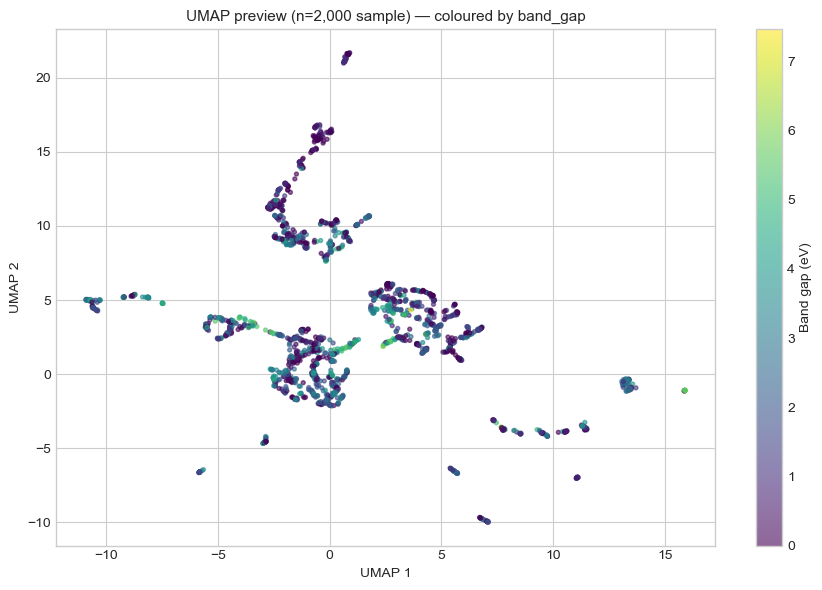

Run the full UMAP on all entries in your Part D.


In [27]:
# Cell DEMO 1 - Quick UMAP preview (n_neighbors=15, subsample for speed)
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    # Subsample for the live demo — full UMAP takes 3-5 min
    sample_idx = np.random.RandomState(42).choice(len(X_scaled),
                                                   min(2000, len(X_scaled)),
                                                   replace=False)
    X_sample = X_scaled[sample_idx]

    reducer_preview = umap.UMAP(n_components=2, n_neighbors=15,
                                min_dist=0.1, random_state=42)
    emb_preview = reducer_preview.fit_transform(X_sample)

    bg_sample = df_clean['band_gap'].values[sample_idx]                 if 'band_gap' in df_clean.columns else np.zeros(len(sample_idx))

    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(emb_preview[:,0], emb_preview[:,1],
                    c=bg_sample, cmap='viridis', s=8, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Band gap (eV)')
    ax.set_title(f'UMAP preview (n={len(sample_idx):,} sample) — coloured by band_gap',
                 fontsize=11)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    plt.tight_layout()
    plt.savefig('Day2_umap_preview.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Run the full UMAP on all entries in your Part D.")

**Day 2 Discussion questions:**

1. From Demo 1: in the UMAP preview, do you see distinct clusters or a continuous manifold? Which part of composition space do you expect to occupy each cluster? Your Part D will run this on the full dataset.

---
## Submission Checklist

Before submitting, confirm all cells have been executed:

- [ ] B1: Scree plot saved (`B1_scree.png`)
- [ ] B2: Biplot saved (`B2_biplot.png`)
- [ ] B4: Band-gap biplot saved and reflection filled in
- [ ] C1–C2: PCA projection scatters saved
- [ ] C3: PC3/PC4 scatter saved and reflection filled in
- [ ] D1: UMAP embedding saved (`D1_umap_embedding.npy`)
- [ ] D2–D4: Three UMAP scatters saved
- [ ] D5: n_neighbors comparison saved and reflection filled in
- [ ] E1: Elbow + silhouette saved; optimal k reported
- [ ] E2–E4: All three clustering results on UMAP saved
- [ ] E5: Comparison table printed and reflection filled in
- [ ] F1–F3: Per-cluster stats printed; reflections filled in
- [ ] F4: Annotated UMAP saved (`F4_annotated_umap.png`) with real chemical family labels
- [ ] G1–G3: All reflection cells answered
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week9.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.
**Submit via Canvas by Sunday 11:59 PM.**